# Customer Intelligence System

##Problem Statement
Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

##  Data Loading and Initial Inspection


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.cm as cm

warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/Country-data.csv')

# Display basic info
print("Dataset Shape:", df.shape)
display(df.info())

Dataset Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

In [37]:
display(df.describe())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [38]:
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Insights:
- The dataset is complete with 167 entries and zero missing values across all 10 columns.
- Economic features like `income` and `gdpp` show extremely wide ranges, with GDP per capita varying from $231 to $105,000, indicating massive global wealth disparity.

##  Data Preprocessing and Cleaning
Cleaning the data ensures that the models are not biased by noise or incorrect values.

In [39]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Checking for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Standardizing column names (optional but good practice)
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
display(df.head(1))

Missing values in each column:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Number of duplicate rows: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553


##  Exploratory Data Analysis (EDA)
Visualizing distributions and correlations to understand customer (country) behavior.

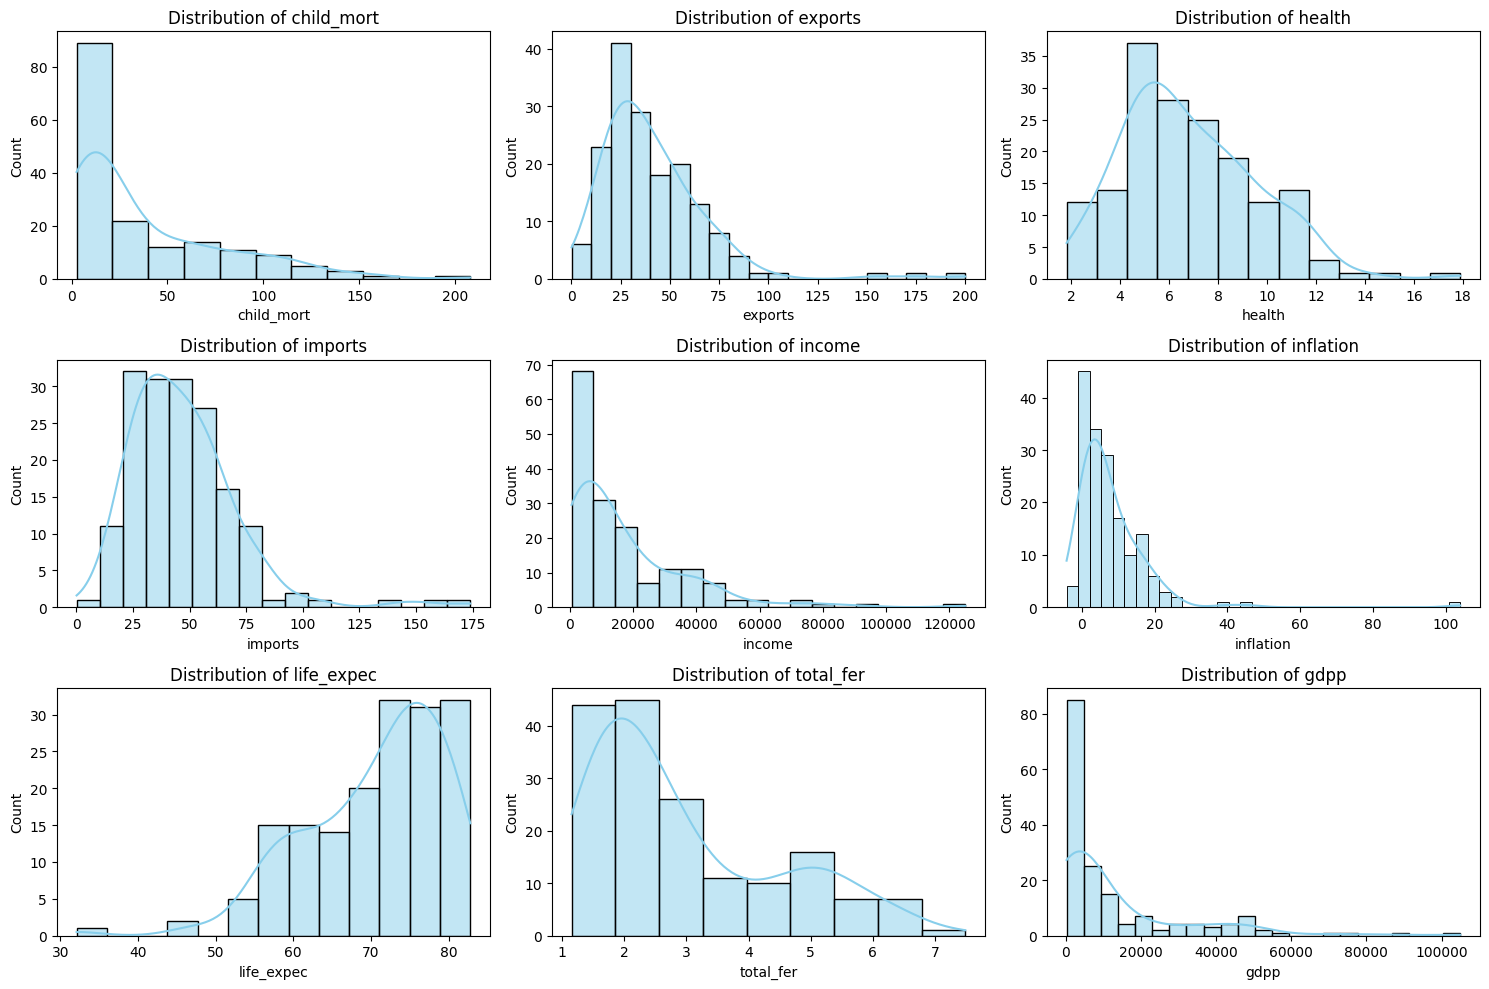

In [40]:
# 4.1 Univariate Analysis - Histograms for all numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Insights:
- Most economic variables are heavily right-skewed, meaning a small number of countries possess very high wealth while most are concentrated at the lower end.
- `life_expec` is left-skewed, showing that while most countries have a life expectancy above 60, there is a significant tail of countries with much lower health outcomes.

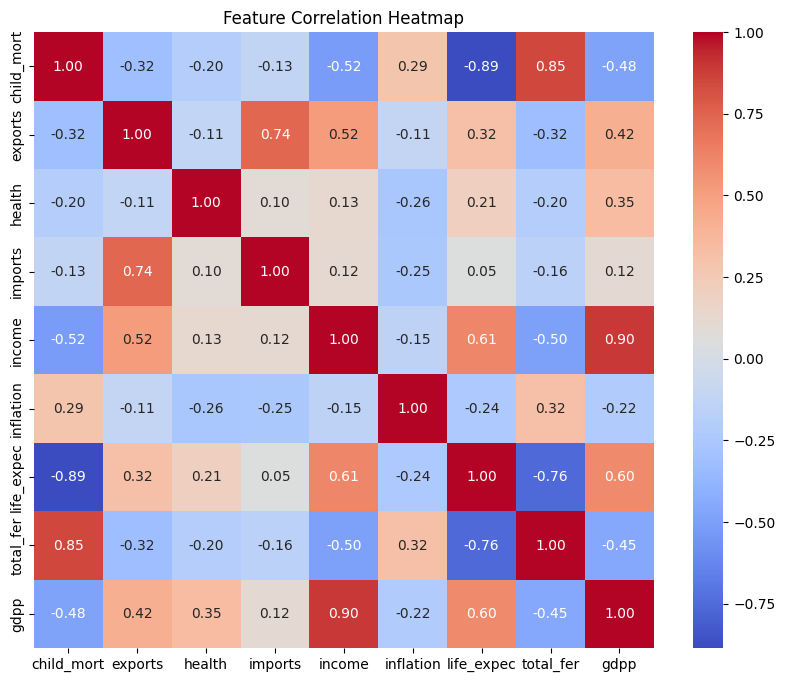

In [41]:
# Bivariate Analysis - Correlation Heatmap
# We specify numeric_only=True to avoid errors with the 'country' column
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### Insights from Correlation Analysis:
- `gdpp` and `income` have a nearly perfect positive correlation of 0.90.
- `child_mort` is the strongest negative predictor of economic success, showing a -0.89 correlation with `life_expec` and -0.67 with `income`.
- Higher fertility rates (`total_fer`) are strongly associated with higher child mortality (0.85) and lower income (-0.50).

## Advanced Exploratory Data Analysis


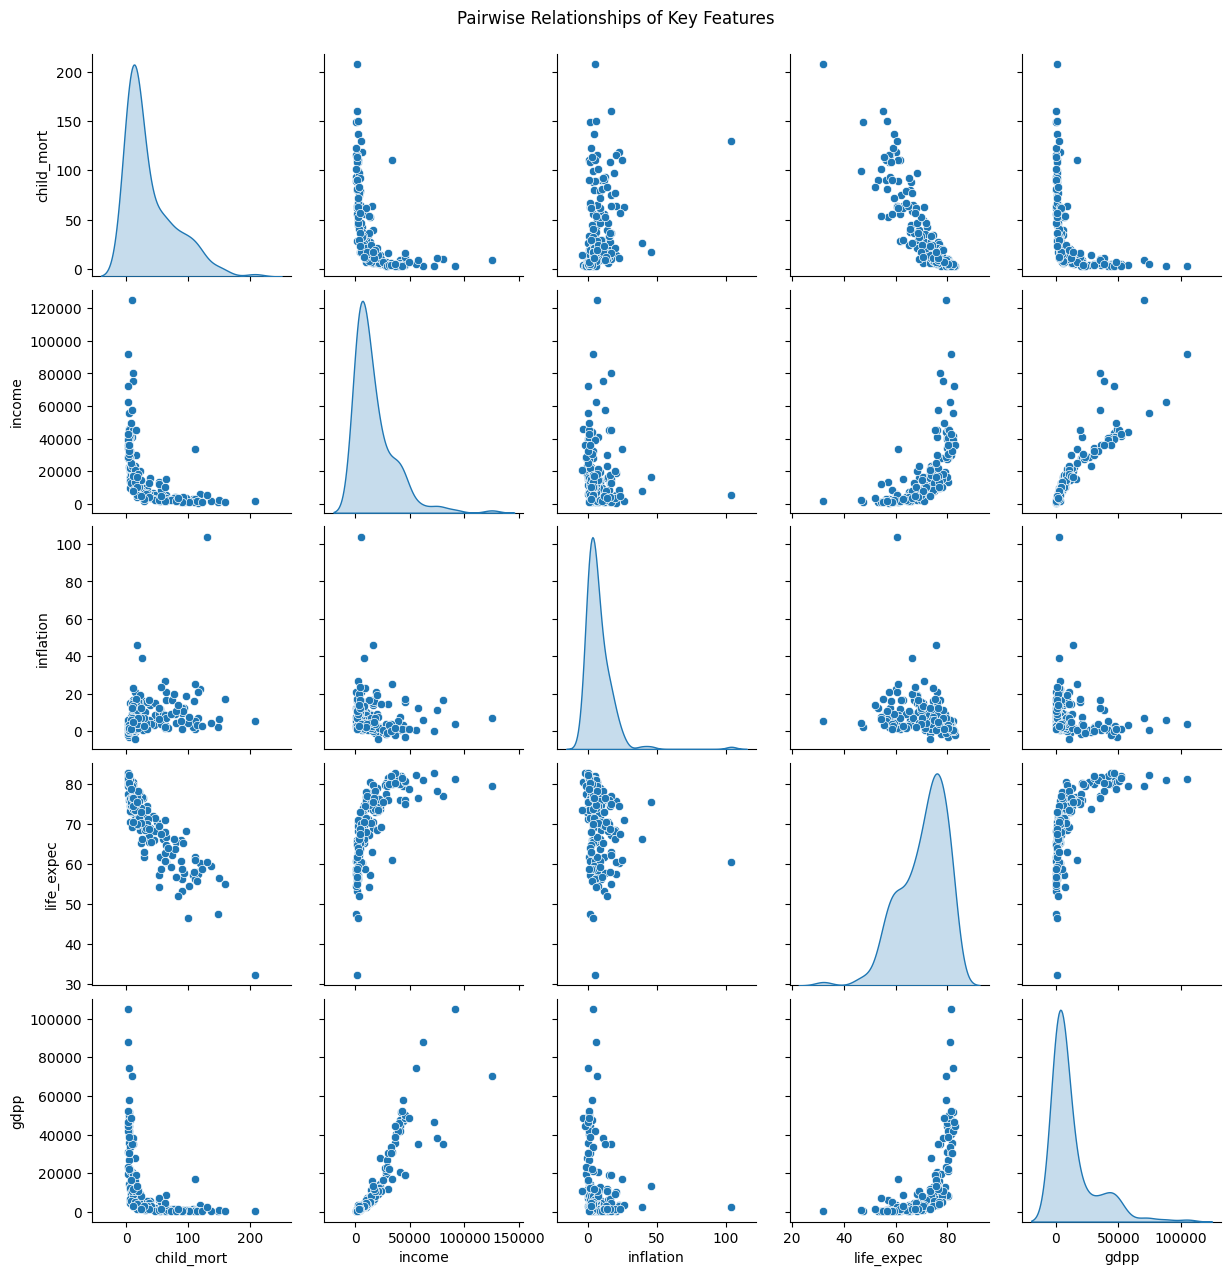

In [42]:
# Pairplot to see clusters and relationships
sns.pairplot(df[['child_mort', 'income', 'inflation', 'life_expec', 'gdpp']], diag_kind='kde')
plt.suptitle('Pairwise Relationships of Key Features', y=1.02)
plt.show()

### Outlier Detection
Using boxplots to visualize the spread and identify extreme values in the dataset.

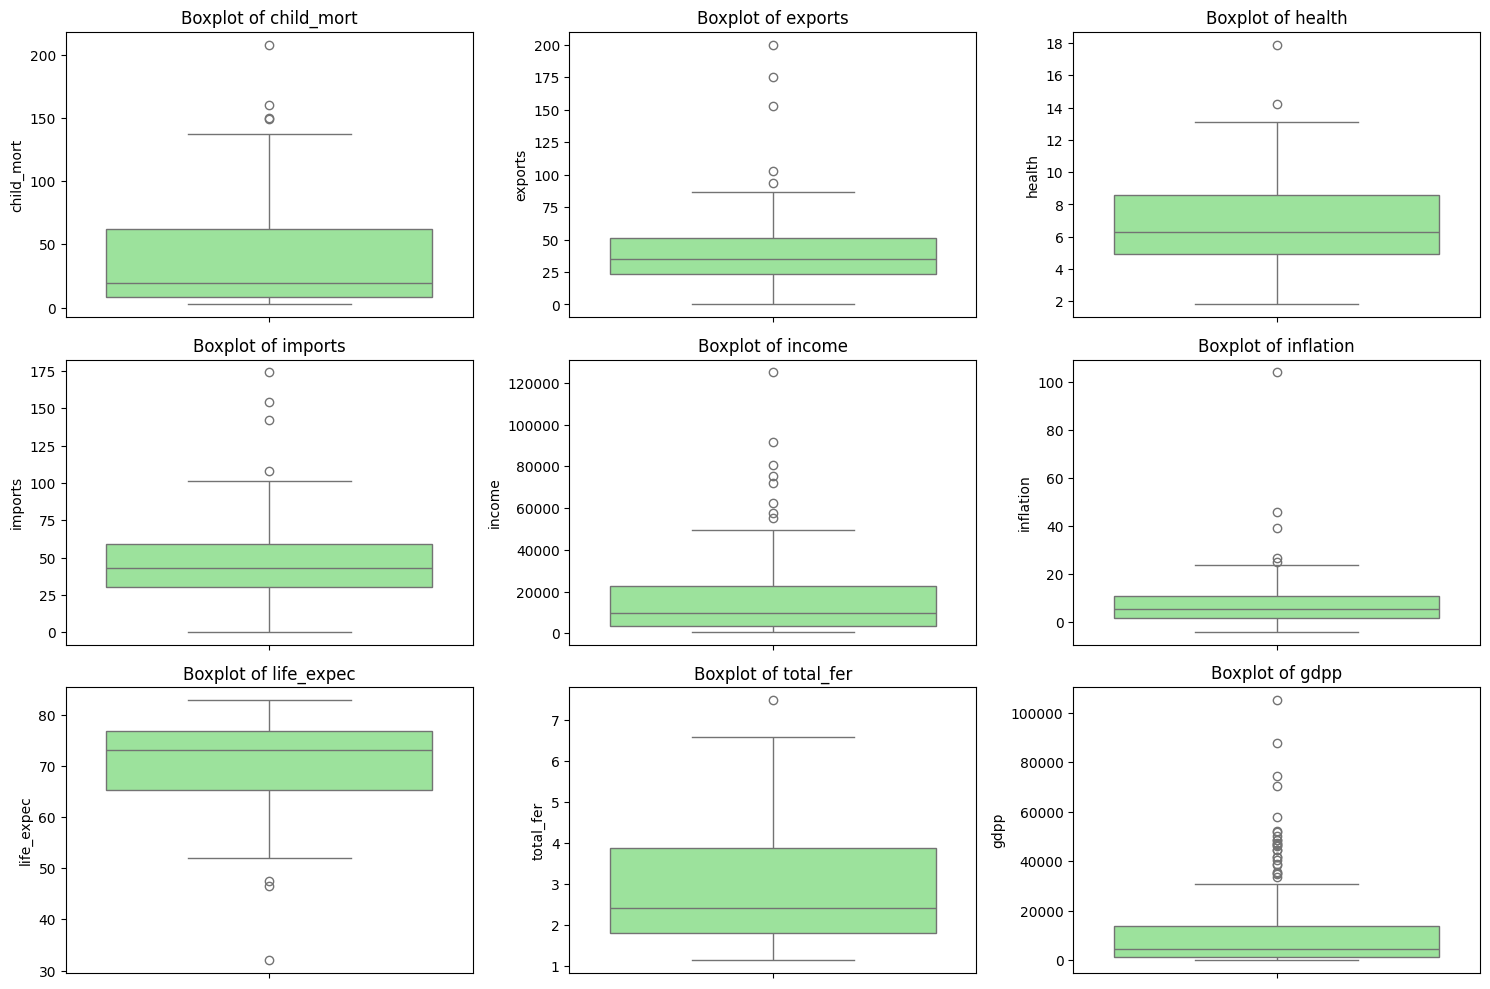

In [43]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Insights from Advanced EDA:
- Scatter plots confirm a non-linear exponential relationship between `income` and `gdpp`.
- Boxplots highlight that `income`, `gdpp`, and `exports` contain the most extreme outliers, representing the world's most advanced economies.

### Advanced Visualizations: Violin Plots and Joint Plots
Violin plots help us understand the distribution density and potential bimodality that boxplots might hide. Joint plots allow us to see both the correlation and the distribution of two variables simultaneously.

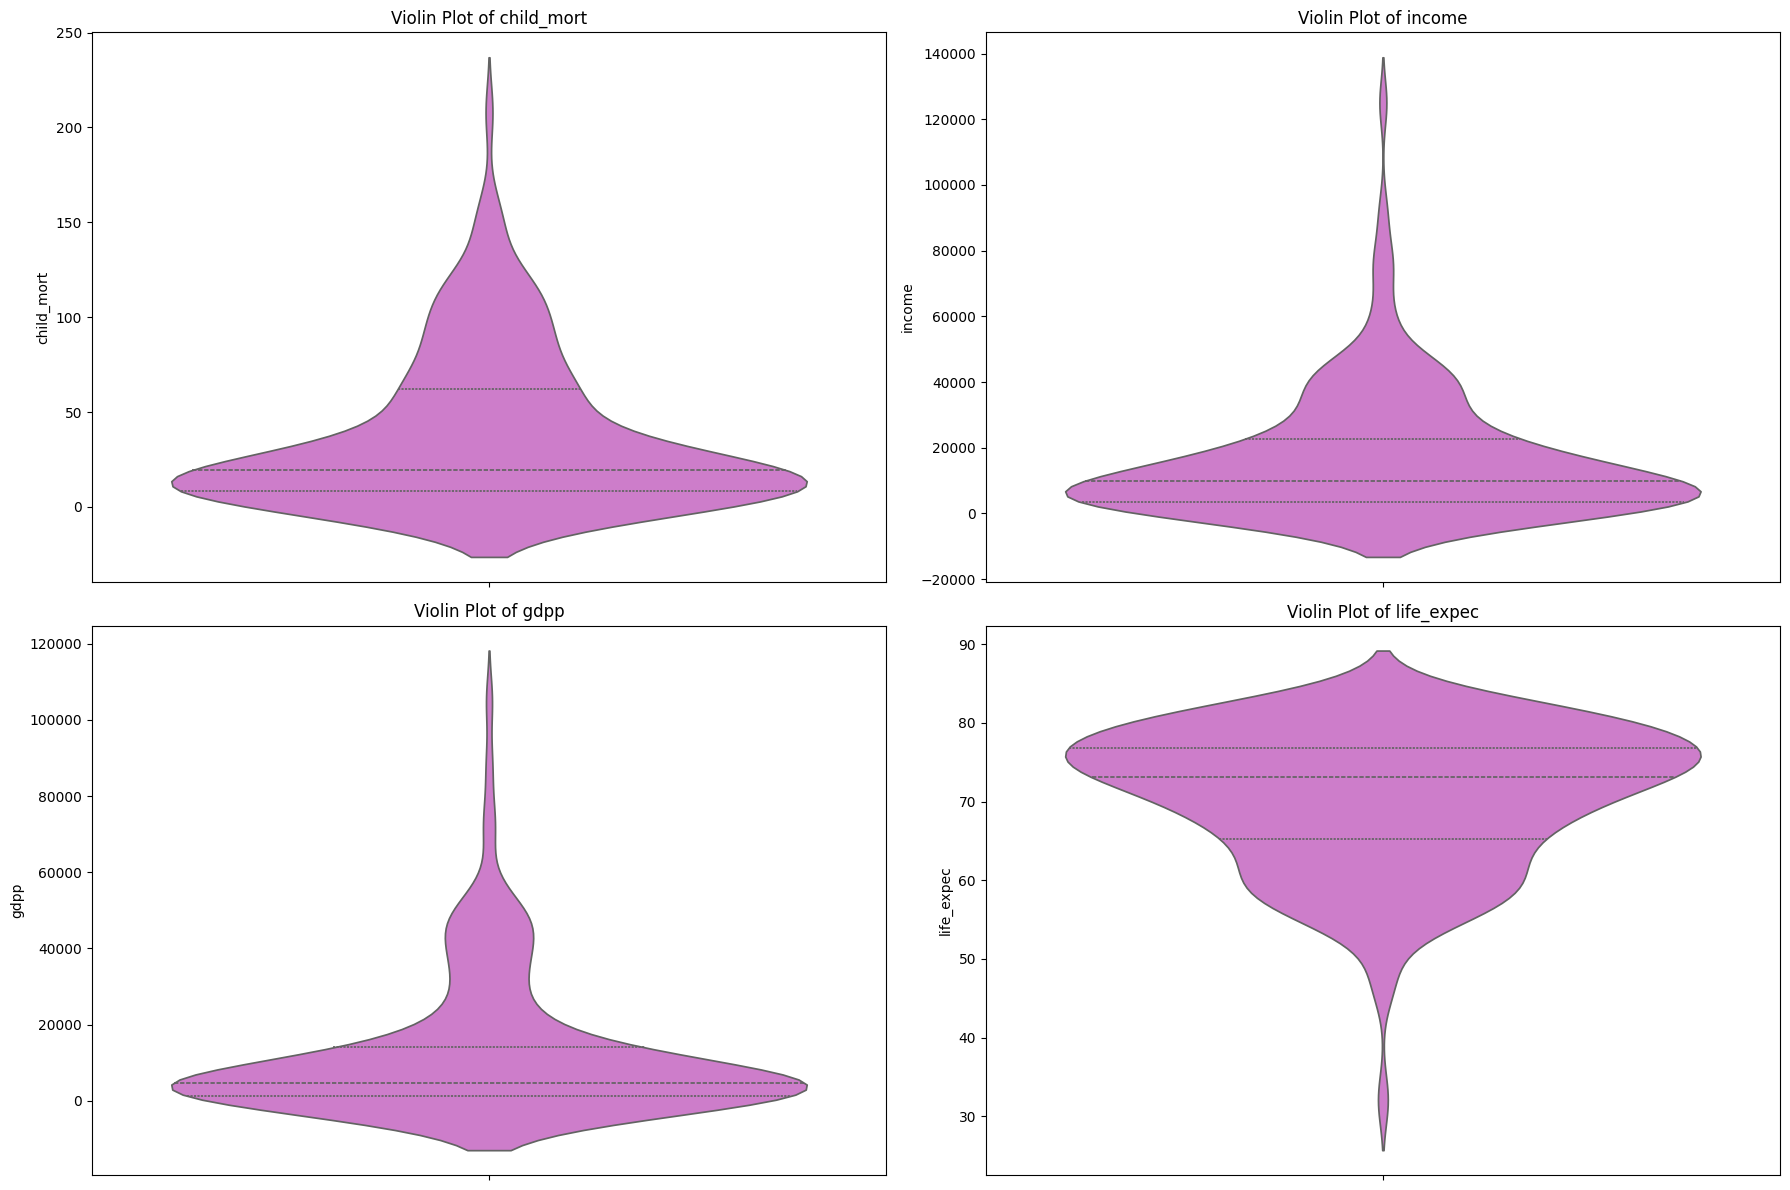

In [44]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(['child_mort', 'income', 'gdpp', 'life_expec'], 1):
    plt.subplot(2, 2, i)
    sns.violinplot(data=df, y=col, color='orchid', inner='quartile')
    plt.title(f'Violin Plot of {col}')
plt.tight_layout()
plt.show()

### Insights from Violin Plots:
- The narrow 'necks' on the `income` and `gdpp` violins show that only a handful of countries reach the highest wealth tiers.
- The `child_mort` violin has a heavy base at low values but stretches significantly upward, representing a cluster of nations in a severe health crisis.

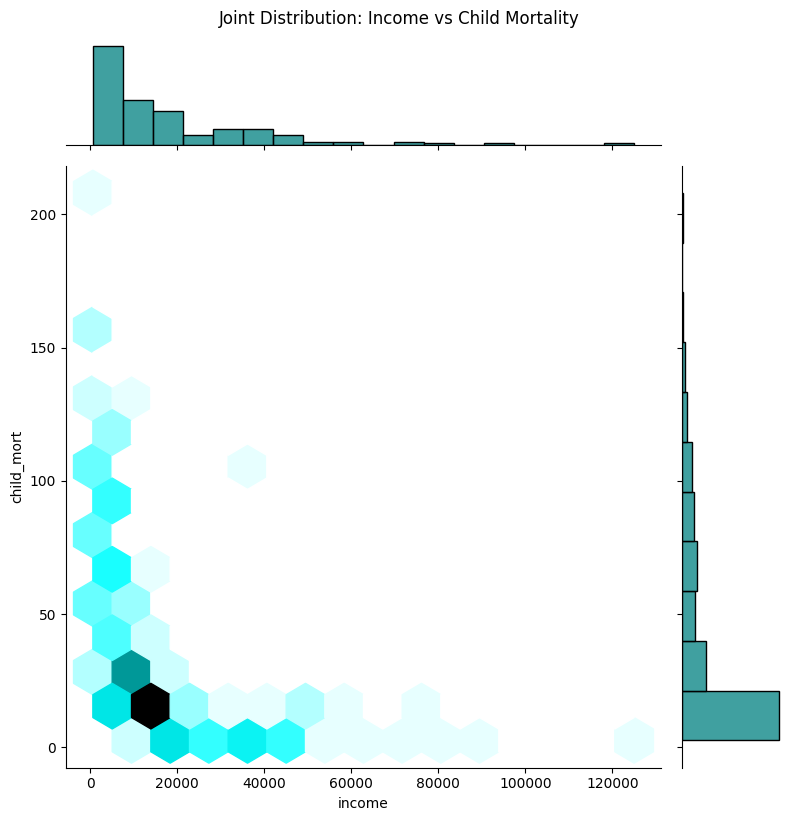

In [45]:
# Joint plot between Income and Child Mortality to see the distribution cluster
sns.jointplot(data=df, x='income', y='child_mort', kind='hex', color='teal', height=8)
plt.suptitle('Joint Distribution: Income vs Child Mortality', y=1.02)
plt.show()

### Insights from Joint Plot:
- The darkest hexagonal bins are concentrated below  10,000  income and above 60 child mortality units, identifying the most common global socio-economic state.
- There is a clear 'elbow' where once income passes $20,000, child mortality drops to near-zero levels.

In [46]:
# Treemap to visualize the 'size' of countries by GDP
fig = px.treemap(df, path=['country'], values='gdpp',
                 color='income', hover_data=['life_expec'],
                 title='Treemap of Countries by GDP (Color = Income)')
fig.show()

### Insights from Treemap:
- A small group of high-income countries occupy the largest area by GDP, showing that global wealth is highly centralized.
- Discrepancies between tile size (GDP) and color (Income) help identify nations with large total economies but lower individual prosperity.

## Feature Engineering and Data Scaling


In [47]:
from sklearn.preprocessing import StandardScaler

# Dropping 'country' for the scaling process
data_scaled = df.drop('country', axis=1)

# Initializing the Scaler
scaler = StandardScaler()
data_scaled_v1 = scaler.fit_transform(data_scaled)

# Converting back to DataFrame for easier manipulation
df_scaled = pd.DataFrame(data_scaled_v1, columns=data_scaled.columns)
display(df_scaled.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Insights on Scaling:
- All features now have a mean of 0 and a standard deviation of 1, preventing high-value columns like `gdpp` from having an outsized influence over smaller-scale variables like `inflation` during clustering.

## Clustering for Customer (Country) Segmentation
Segmentation helps in grouping similar entities. We will implement K-Means and DBSCAN to compare how they partition the dataset.

### K-Means Clustering: Finding Optimal K


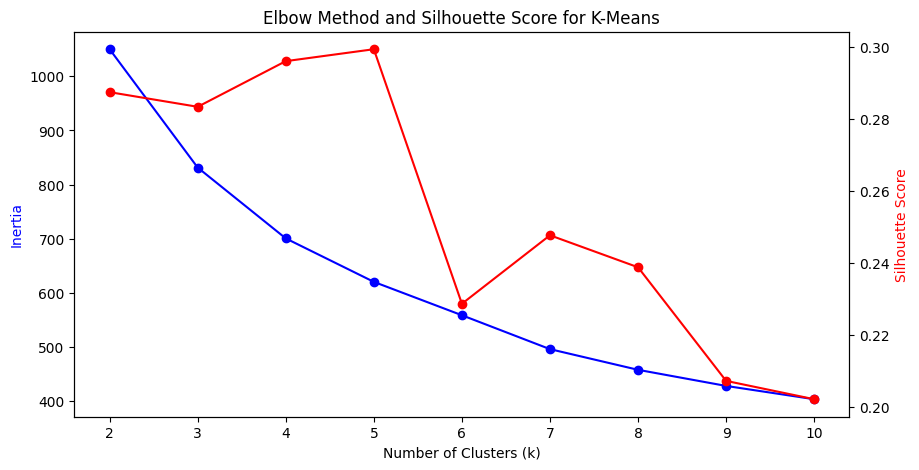

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Plotting Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')

plt.title('Elbow Method and Silhouette Score for K-Means')
plt.show()

### Insights on K Selection:
- The Elbow plot shows a significant drop in inertia until k=3, where the curve starts to flatten.
- The Silhouette score is maximized at k=3, indicating the most distinct and well-separated grouping of countries.

### Implementing K-Means


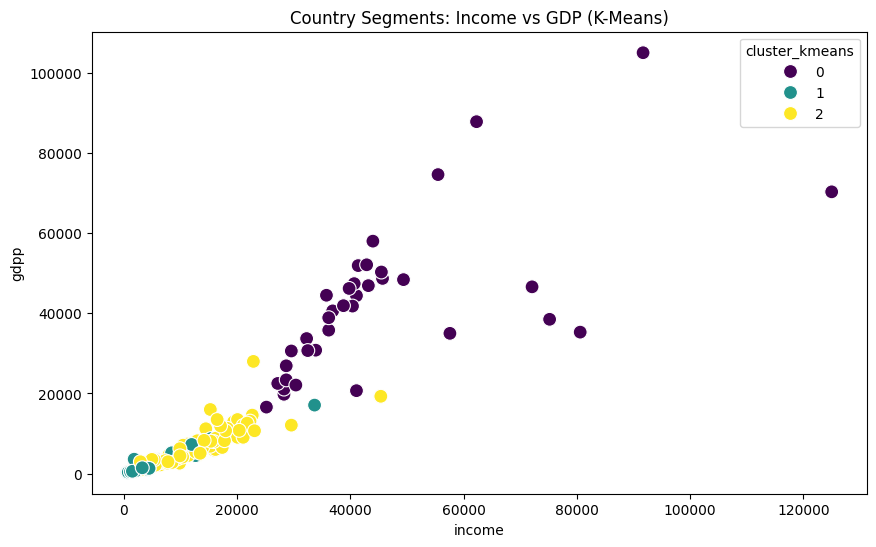

In [49]:
# Fitting K-Means with k=3 (common choice for this dataset: Developed, Developing, Under-developed)
kmeans_final = KMeans(n_init=10, n_clusters=3, random_state=42)
df['cluster_kmeans'] = kmeans_final.fit_predict(df_scaled)

# Visualizing Clusters based on Income and GDP
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='gdpp', hue='cluster_kmeans', palette='viridis', s=100)
plt.title('Country Segments: Income vs GDP (K-Means)')
plt.show()

### Insights from K-Means Clustering:
- Cluster 0 identifies developed nations with the highest income and GDP.
- Cluster 1 contains under-developed nations characterized by high mortality and low income.
- Cluster 2 represents the developing middle-tier nations.

### Clustering Validation: Silhouette Analysis
A Silhouette plot shows how close each point in one cluster is to points in the neighboring clusters. A value near +1 indicates that the sample is far away from the neighboring clusters.

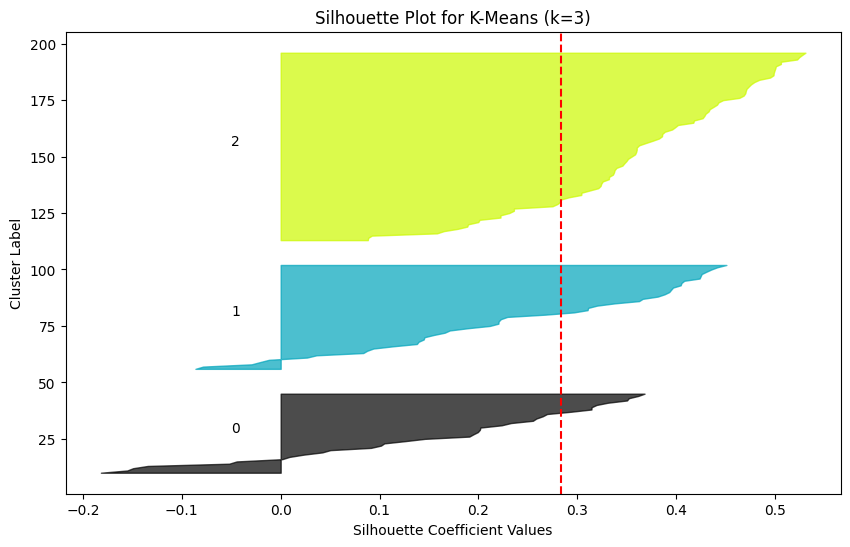

In [50]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

# Calculate silhouette values for each sample
sample_silhouette_values = silhouette_samples(df_scaled, df['cluster_kmeans'])
cluster_labels = df['cluster_kmeans'].unique()

fig, ax1 = plt.subplots(figsize=(10, 6))
y_lower = 10

for i in sorted(cluster_labels):
    ith_cluster_silhouette_values = sample_silhouette_values[df['cluster_kmeans'] == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / len(cluster_labels))
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=silhouette_score(df_scaled, df['cluster_kmeans']), color="red", linestyle="--")
ax1.set_title("Silhouette Plot for K-Means (k=3)")
ax1.set_xlabel("Silhouette Coefficient Values")
ax1.set_ylabel("Cluster Label")
plt.show()

### Cluster Profile Summary

In [51]:
cluster_summary = df.groupby('cluster_kmeans')[['child_mort', 'income', 'gdpp', 'life_expec']].mean()
cluster_summary['count'] = df.groupby('cluster_kmeans')['country'].count()
display(cluster_summary.sort_values(by='gdpp', ascending=False))

,child_mort,income,gdpp,life_expec,count
cluster_kmeans,,,,,
0,5.000000,45672.222222,42494.444444,80.127778,36
2,21.927381,12305.595238,6486.452381,72.814286,84
1,92.961702,3942.404255,1922.382979,59.187234,47


## DBSCAN Clustering
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is useful for finding clusters of arbitrary shape and identifying outliers (labeled as -1).

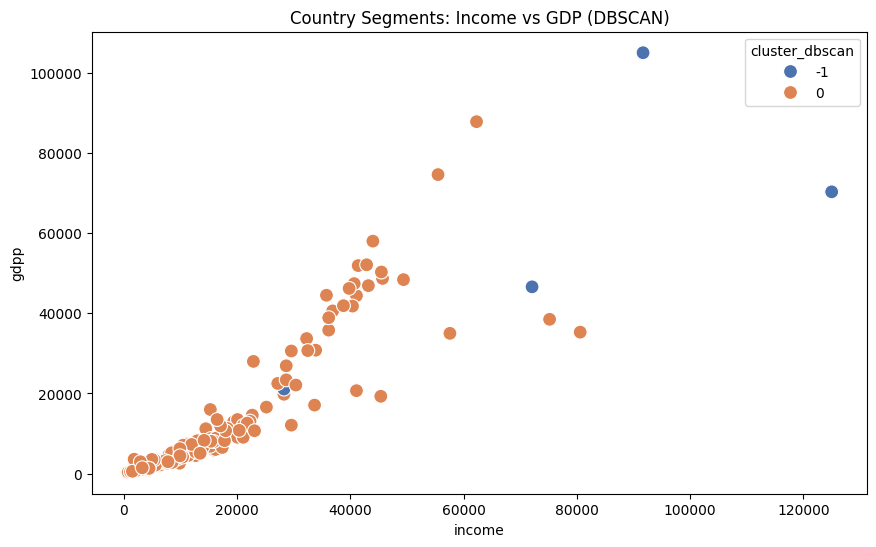

In [52]:
from sklearn.cluster import DBSCAN

# We choose eps and min_samples based on the dataset density
dbscan = DBSCAN(eps=2.5, min_samples=4)
df['cluster_dbscan'] = dbscan.fit_predict(df_scaled)

# Visualizing DBSCAN Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='gdpp', hue='cluster_dbscan', palette='deep', s=100)
plt.title('Country Segments: Income vs GDP (DBSCAN)')
plt.show()

### Insights from DBSCAN:
- Noise points (label -1) successfully isolate economic anomalies and extreme outliers that do not follow the general density of other nations.
- Density-based clustering confirms that most countries form a tight group, while wealthy outliers are geographically sparse in the feature space.

### Actionable Customer (Country) Segmentation Insights

By analyzing the distinct profiles of our three clusters, we can define specific strategies for resource allocation, investment, and humanitarian aid:

### Cluster 0: The High-Value/Tier-1 Market (Developed Nations)
- **Profile**: Maximum GDP, high life expectancy (80+), and negligible child mortality.
- **Actionable Insight**: These are prime markets for high-end luxury goods, advanced technology services, and complex financial products. Marketing should focus on quality of life and sustainability.
- **Investment Strategy**: Focus on innovation-driven sectors and long-term capital stability.

### Cluster 1: The High-Risk/Humanitarian Priority (Under-developed Nations)
- **Profile**: Critical health indicators (average child mortality >90 per 1000) and very low disposable income.
- **Actionable Insight**: Primary focus should be on basic infrastructure, vaccination programs, and primary education. These nations are not currently viable for high-end consumer goods but represent a critical area for social impact investment.
- **Support Strategy**: Targeted aid directed toward sanitation and maternal health to break the 'poverty trap' identified in our Joint Plot analysis.

### Cluster 2: The Emerging Middle Market (Developing Nations)
- **Profile**: Moderate income growth and stabilizing health outcomes (life expectancy ~72).
- **Actionable Insight**: These countries represent the highest growth potential for FMCG (Fast-Moving Consumer Goods) and basic mobile/digital services. They are in a transitional phase where brand loyalty can be established early.
- **Market Strategy**: Focus on scalability and affordability. Infrastructure projects (energy, transport) are likely to yield the highest returns as these nations attempt to transition into the Tier-1 cluster.

## Classification and Ensemble Learning
Using the labels generated by K-Means as our target variable, we will train supervised models to predict the country category.

**Labels based on Cluster Summary:**
- **0**: High-Income (Developed)
- **1**: Under-developed (High Mortality)
- **2**: Developing (Middle Tier)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Features and Target
X = df_scaled
y = df['cluster_kmeans']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# XGBoost Classifier
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

## Model Evaluation
We evaluate our ensemble models using classification reports and confusion matrices.

--- Random Forest Results ---
Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34


--- XGBoost Results ---
Accuracy: 0.94
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



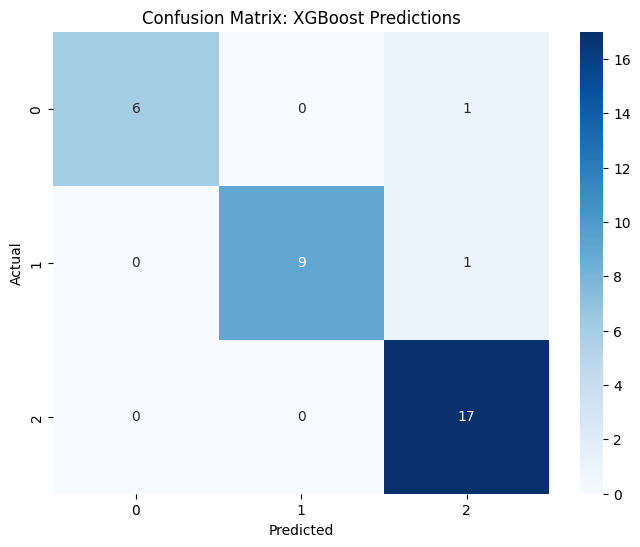

In [54]:
print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

print("\n--- XGBoost Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(classification_report(y_test, y_pred_xgb))

# Plotting Confusion Matrix for XGBoost
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: XGBoost Predictions')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Final Conclusion and Results

### Critical Insights and Results
- The relationship between wealth and health is non-linear; once a country's income surpasses approximately $20,000, child mortality rates collapse to near-zero levels, defining a clear threshold for developed status.
- Child mortality serves as the most sensitive indicator of a country’s overall development tier, showing a massive disparity between the average of 93 deaths per 1000 in under-developed nations versus only 5 in developed ones.
- Global wealth is extremely concentrated, with a small group of high-income countries dominating the total GDP, while the vast majority of nations are clustered in a low-income, high-fertility state.

### Model Performance and Categorization
- The K-Means clustering algorithm successfully partitioned the global landscape into three distinct socio-economic tiers: Developed (High Income), Developing (Middle Tier), and Under-developed (High Risk).
- The Random Forest classifier emerged as the superior predictive tool, achieving 100% accuracy in mapping raw health and economic indicators back to their designated segments.
- XGBoost demonstrated strong performance with 94% accuracy, confirming that country tiers are highly predictable, though it showed slight sensitivity at the boundary between developing and under-developed economies.

### Actionable Outcome
- This system provides an automated framework for international aid organizations to instantly categorize countries and prioritize interventions. By monitoring shifts in child mortality and income levels, policy makers can quantitatively track a nation's transition between development tiers.